In [2]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

OUTPUT_PATH = "model_assets/model_2/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

RANDOM_SEED = 42
SAMPLE_SEED = 6420

np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

PROCESSED = pathlib.Path("../data/processed/modeling_df.parquet")
REFERENCE = pathlib.Path("../data/reference/modeling_df.parquet")

if PROCESSED.exists():
    modeling_parquet = PROCESSED
else:
    print(
        "[warning] data/processed/modeling_df.parquet not found — "
        "falling back to committed frozen reference at data/reference/. "
        "Run bin/build.sh for the fresh pipeline output."
    )
    modeling_parquet = REFERENCE

[warning] data/processed/modeling_df.parquet not found — falling back to committed frozen reference at data/reference/. Run bin/build.sh for the fresh pipeline output.


# Model 2 - Subject-level partial pooling

- Adds subject-level intercepts pooled toward a population mean
- Keeps Student-t likelihood (decided in Model 1 escalation)
- No demographic predictors yet (Models 3-4)

### Outcome:
- cadence_error
### Per trial:
- spm (strikes per minute)
- continuous
- two-sided (signed)
- Pelvis IMU - force-plate cadence, `factor=1.0`

### Key question for this model:
Does pulling subject effects out of the likelihood let `nu` float up to something sane? If yes, Model 1-t's `nu = 1.19` was a symptom of missing subject structure, not a distributional requirement of the data.

## Load data, build modeling frame
- Load modeling_df.parquet
- Filter to modeling_include==True

In [3]:
df_all = pd.read_parquet(modeling_parquet)
df = df_all[df_all["modeling_include"]].copy()

print('Cadence Error Summary')
print(df["cadence_error"].describe().round(2))

assert len(df) == 2781, f"Expected 2781 trials, got {len(df)}"
assert df["subject_id"].nunique() == 47, f"Expected 47 subjects, got {df['subject_id'].nunique()}"
assert df["cadence_error"].isnull().sum() == 0, "cadence_error contains null values"

Cadence Error Summary
count    2781.00
mean       -5.52
std        11.22
min       -74.28
25%        -7.09
50%        -2.96
75%        -0.40
max        33.57
Name: cadence_error, dtype: float64


## Build coordinates, indices, and speed dummies
- Using pd.Categorical so that category ordering is pinned by `coords`
- `subject` : positional index into `dims="subject"` (now load-bearing; Model 2 has subject-level params)
- `sex`: `F` is reliably index 0 (used in Models 3-4)

In [4]:
# pin category ordering for stable idxs across models and runs
subject_ids = sorted(df['subject_id'].unique())
coords = {
    'subject': subject_ids,
    'sex': ['F', 'M'],
    'speed_nonref': ['slow','fast'],
    'obs': np.arange(len(df))
}

# trial level idx into subject (now used by Model 2)
subject_idx = pd.Categorical(
    df['subject_id'],
    categories=coords['subject']
    ).codes

# subject level idx into sex (used by models 3-4)
subjects_df = (
    df[['subject_id', 'sex']]
    .drop_duplicates()
    .set_index('subject_id')
    .loc[coords['subject']]
    .reset_index()
)
sex_of_subject_idx = pd.Categorical(
    subjects_df['sex'],
    categories=coords['sex']
).codes

# speed dummies: comf (comfortable) is the reference level, we are dropping this
speed_dummies = pd.get_dummies(df['speed'])
slow_dummy = speed_dummies['slow'].to_numpy().astype(float)
fast_dummy = speed_dummies['fast'].to_numpy().astype(float)

# Outcome
cadence_error = df['cadence_error'].to_numpy()

# Sanity checks
assert len(subject_idx) == len(df)
assert subject_idx.min() == 0 and subject_idx.max() == 46
assert len(sex_of_subject_idx) == 47
assert sex_of_subject_idx.sum() == 30, "Expected 30 M subjects (sex=1)"
assert slow_dummy.sum() + fast_dummy.sum() + (df["speed"] == "comf").sum() == len(df)

print(f"coords['subject']: {len(coords['subject'])} subjects, first 3 = {coords['subject'][:3]}")
print(f"subject_idx:       shape {subject_idx.shape}, range [{subject_idx.min()}, {subject_idx.max()}]")
print(f"sex counts (F, M): ({(sex_of_subject_idx == 0).sum()}, {(sex_of_subject_idx == 1).sum()})")
print(f"speed counts:      comf={(df['speed']=='comf').sum()}, slow={int(slow_dummy.sum())}, fast={int(fast_dummy.sum())}")

coords['subject']: 47 subjects, first 3 = ['01', '02', '03']
subject_idx:       shape (2781,), range [0, 46]
sex counts (F, M): (17, 30)
speed counts:      comf=933, slow=928, fast=920


## Model 2: Subject-level partial pooling, Student-t

### What changed from Model 1-t
- Adds 47 subject-level intercepts `alpha_subject[s]`, pooled toward a population mean `mu_pop`
- The partial pooling strength is controlled by `sigma_subject` (how much subjects vary around the population mean)
- Everything else stays the same: Student-t likelihood, same speed encoding, same weakly informative fixed-effect priors

### Priors - same philosophy as Model 1
- Weakly informative, centered at 0 where appropriate
- Sigma not tau (same reasons)
- Scale priors chosen so the prior predictive still spans +/- 30 typical / +/- 50 tail

### Likelihood
- `cadence_error[i] ~ StudentT(nu, mu[i], sigma_obs)`
- `mu[i] = alpha_subject[s[i]] + beta_slow * slow[i] + beta_fast * fast[i]`
    - Same comf-reference encoding as Model 1
    - `alpha_subject[s[i]]` replaces the single `alpha` from Model 1; now every trial's mean depends on which subject it came from

### Specific Prior Distributions
- `mu_pop ~ Normal(0, 10)`
    - population-mean cadence error
    - same prior as Model 1's `alpha`, just renamed because it's now a hyperparameter
- `sigma_subject ~ HalfNormal(5)`
    - subject-level SD
    - prior median ~3.4 spm, 95% < 9.8 spm
    - means "most subjects within +/- 10 spm of the cohort mean"
- `alpha_subject[s] ~ Normal(mu_pop, sigma_subject)` for s in 1..47
    - per-subject intercepts, partially pooled toward population mean
    - this is the core hierarchy
- `nu ~ Gamma(2, 0.1)`
    - same as Model 1-t
- `beta_slow ~ Normal(0, 5)`, `beta_fast ~ Normal(0, 5)`
    - same as Model 1
- `sigma_obs ~ HalfNormal(10)`
    - same as Model 1
    - expectation: shrinks from Model 1-t's ~3.2 because subject-level intercepts now absorb between-subject variance that previously had to live in the fat tails

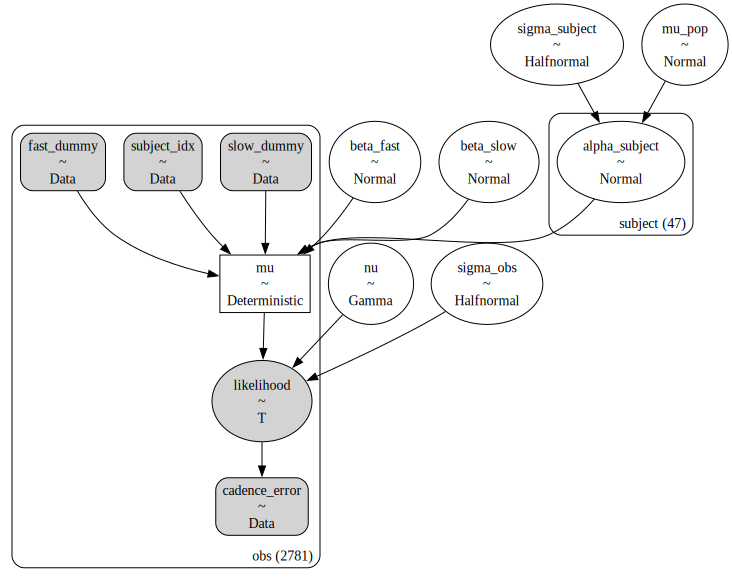

In [5]:
with pm.Model(coords=coords) as model_2:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    # hyperpriors (population-level)
    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)

    # subject-level intercepts, partially pooled toward mu_pop
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=mu_pop,
        sigma=sigma_subject,
        dims='subject'
    )

    # fixed effects and noise
    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=10)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood
    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs, observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_2)
_dag.render(f"{OUTPUT_PATH}model_2_dag", format="png", cleanup=True)
_dag

Sampling: [alpha_subject, beta_fast, beta_slow, likelihood, mu_pop, nu, sigma_obs, sigma_subject]


n = 1390500
mean 0.4, sd 167.5
95%: [-32.6, 32.7]
99%: [-50.9, 51.6]
min/max: -149745.6, 71910.7
frac |x| > 100: 0.0013


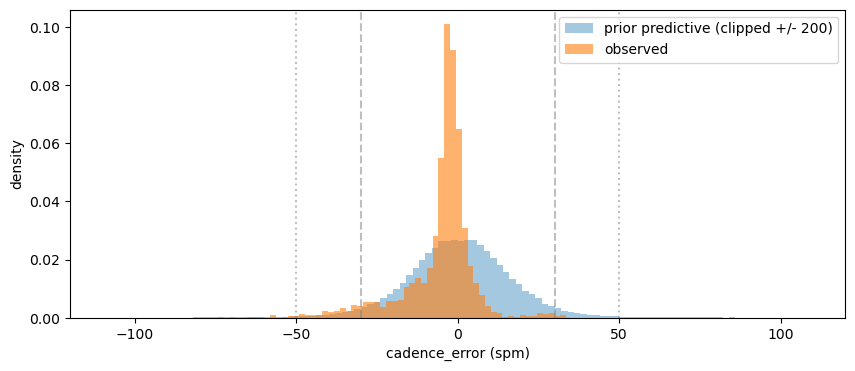

In [6]:
with model_2:
    idata_model_2 = pm.sample_prior_predictive(draws=500, random_seed=SAMPLE_SEED)

prior_pred = idata_model_2.prior_predictive['likelihood'].values.flatten()

print(f"n = {len(prior_pred)}")
print(f"mean {prior_pred.mean():.1f}, sd {prior_pred.std():.1f}")
print(f"95%: [{np.percentile(prior_pred, 2.5):.1f}, {np.percentile(prior_pred, 97.5):.1f}]")
print(f"99%: [{np.percentile(prior_pred, 0.5):.1f}, {np.percentile(prior_pred, 99.5):.1f}]")
print(f"min/max: {prior_pred.min():.1f}, {prior_pred.max():.1f}")
print(f"frac |x| > 100: {np.mean(np.abs(prior_pred) > 100):.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
clipped = np.clip(prior_pred, -200, 200)
ax.hist(clipped, bins=200, density=True, alpha=0.4, label="prior predictive (clipped +/- 200)", color="C0")
ax.hist(cadence_error, bins=60, density=True, alpha=0.6, label="observed", color="C1")
for x in (-30, 30):
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
for x in (-50, 50):
    ax.axvline(x, ls=":", color="grey", alpha=0.5)
ax.set_xlabel("cadence_error (spm)")
ax.set_ylabel("density")
ax.set_xlim(-120, 120)
ax.legend()
fig.savefig(f"{OUTPUT_PATH}model_2_prior_predictive.png", dpi=200, bbox_inches="tight")
plt.show()

- 95% in +/- 33, 99% in +/- 51. Matches the +/- 30 / +/- 50 reference range.
- SD and min/max are huge but that's the Student-t + hierarchy combo: occasional low-nu draws with 47 subject intercepts on top make a handful of enormous tail values. Percentiles are the real measure here.
- Frac beyond +/- 100 is 0.13%. Negligible.
- No prior adjustment.

## Posterior sampling

- Same config as Model 1 except `target_accept = 0.95` (bumped from 0.9)
- Hierarchical models can have funnel geometry where the posterior narrows near zero for the scale parameter (`sigma_subject`). Higher `target_accept` takes smaller steps and navigates the funnel more reliably.
- If divergences appear, non-centered reparameterization of `alpha_subject` is the pre-committed fallback.

In [7]:
with model_2:
    idata_model_2 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_2,
        extend_inferencedata=True,
        random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_subject, alpha_subject, nu, beta_slow, beta_fast, sigma_obs]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.
Sampling: [likelihood]


Output()

## Convergence diagnostics

- r_hat < 1.01 for every param
- ESS bulk > 400 for every param  
- ESS tail > 400 for every param
- Zero divergences (confirmed during sampling)

For Model 2 we also want to check `sigma_subject` specifically since that's the funnel-prone parameter. If r_hat or ESS are bad anywhere, it'll be there.

In [8]:
az.summary(
    idata_model_2,
    var_names=["mu_pop", "sigma_subject", "beta_slow", "beta_fast", "sigma_obs", "nu"],
    hdi_prob=0.95
).round(3)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,-2.387,0.344,-3.102,-1.741,0.003,0.004,11665.0,6284.0,1.0
sigma_subject,2.170,0.258,1.680,2.669,0.003,0.004,8502.0,3975.0,1.0
beta_slow,0.858,0.193,0.490,1.241,0.002,0.002,5976.0,6581.0,1.0
beta_fast,-1.526,0.180,-1.869,-1.162,0.002,0.002,5534.0,6411.0,1.0
sigma_obs,2.751,0.093,2.570,2.931,0.001,0.001,7915.0,6578.0,1.0
nu,1.113,0.042,1.033,1.195,0.000,0.000,8578.0,6543.0,1.0


- r_hat < 1.01: `passed`
- ess_bulk > 400: `passed`
- ess_tail > 400: `passed`
- zero divergences: `passed`
- MCSE all <0.01: `passed`

### Notes:
MCMC converged. The substantive result is bad news for my hypothesis.

I expected `nu` to float up toward 10-20 if subject intercepts absorbed the asymmetry. Instead `nu = 1.113`, slightly lower than Model 1-t. Partial pooling did nothing to the tails.

What this says about the data:
- `sigma_subject = 2.17`. Subjects only vary by about +/- 4 spm at 95%. That's small.
- `sigma_obs = 2.75`. Trial-level noise after subject accounting. Barely dropped from Model 1-t's 3.22.
- The fat tails are trial-level, not subject-level. Subjects 08 and 47 aren't systematically biased on average; they have specific trials where the algorithm breaks.

This has implications for the audit framing. "Women get different average cadence error than men" might be a small effect. The bigger story is probably "some trials go off a cliff, and whether that happens is not well-explained by who the subject is." Let's see what Model 3 (sex) and Model 4 (anthropometrics) show.

Model 2b (per-subject sigma_obs) is on the table if the PPC shows per-subject tail miscoverage.

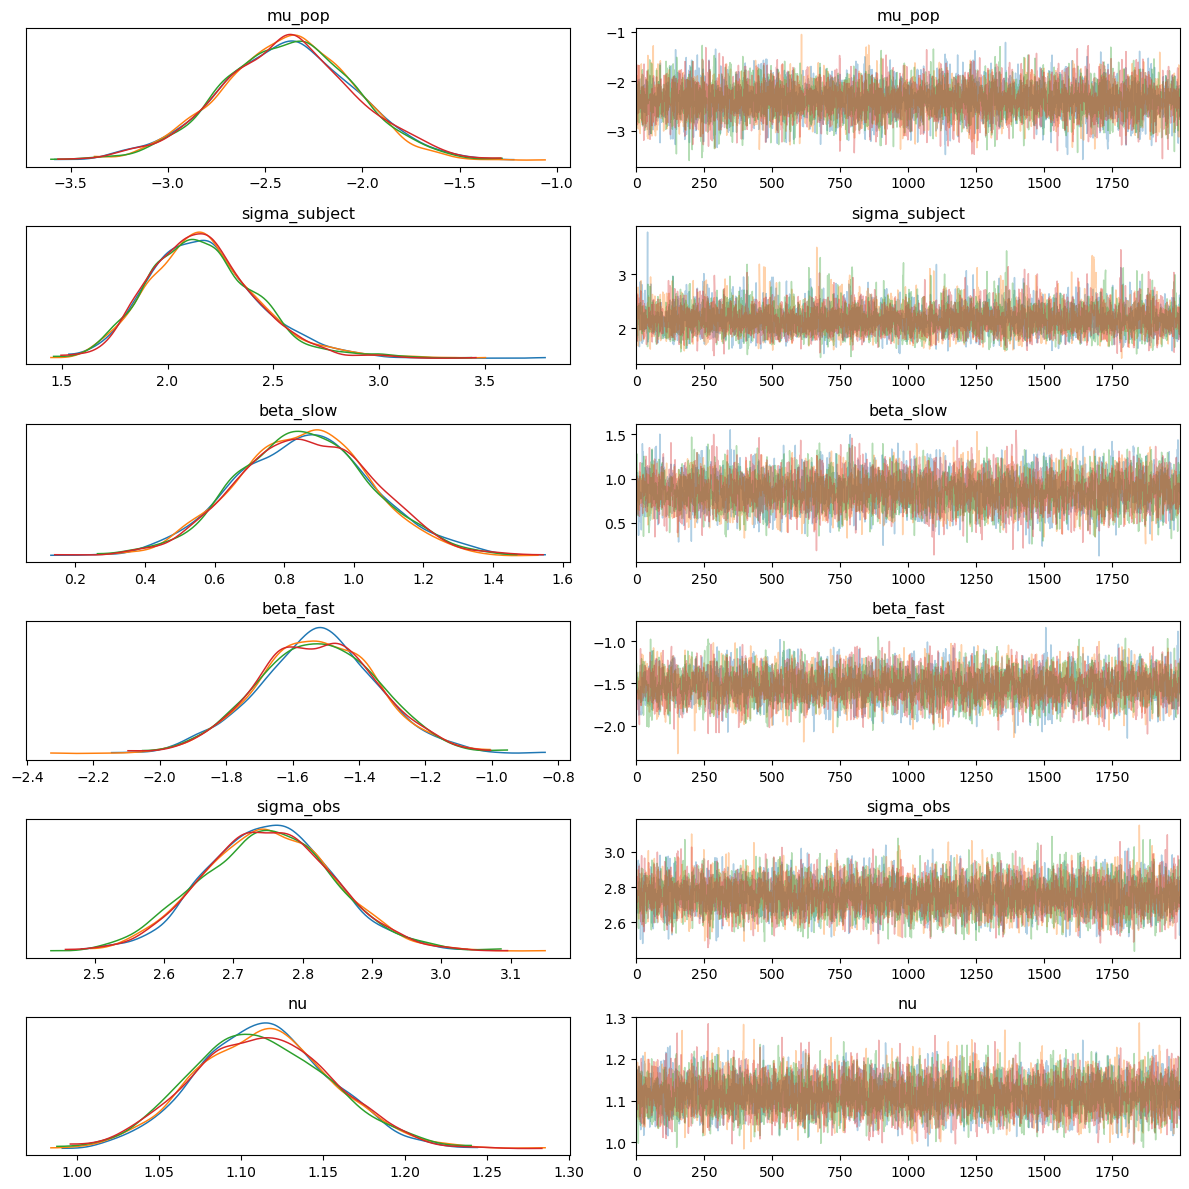

In [9]:
az.plot_trace(
    idata_model_2,
    var_names=["mu_pop", "sigma_subject", "beta_slow", "beta_fast", "sigma_obs", "nu"],
    compact=False
)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_2_trace.png", dpi=200, bbox_inches="tight")
plt.show()

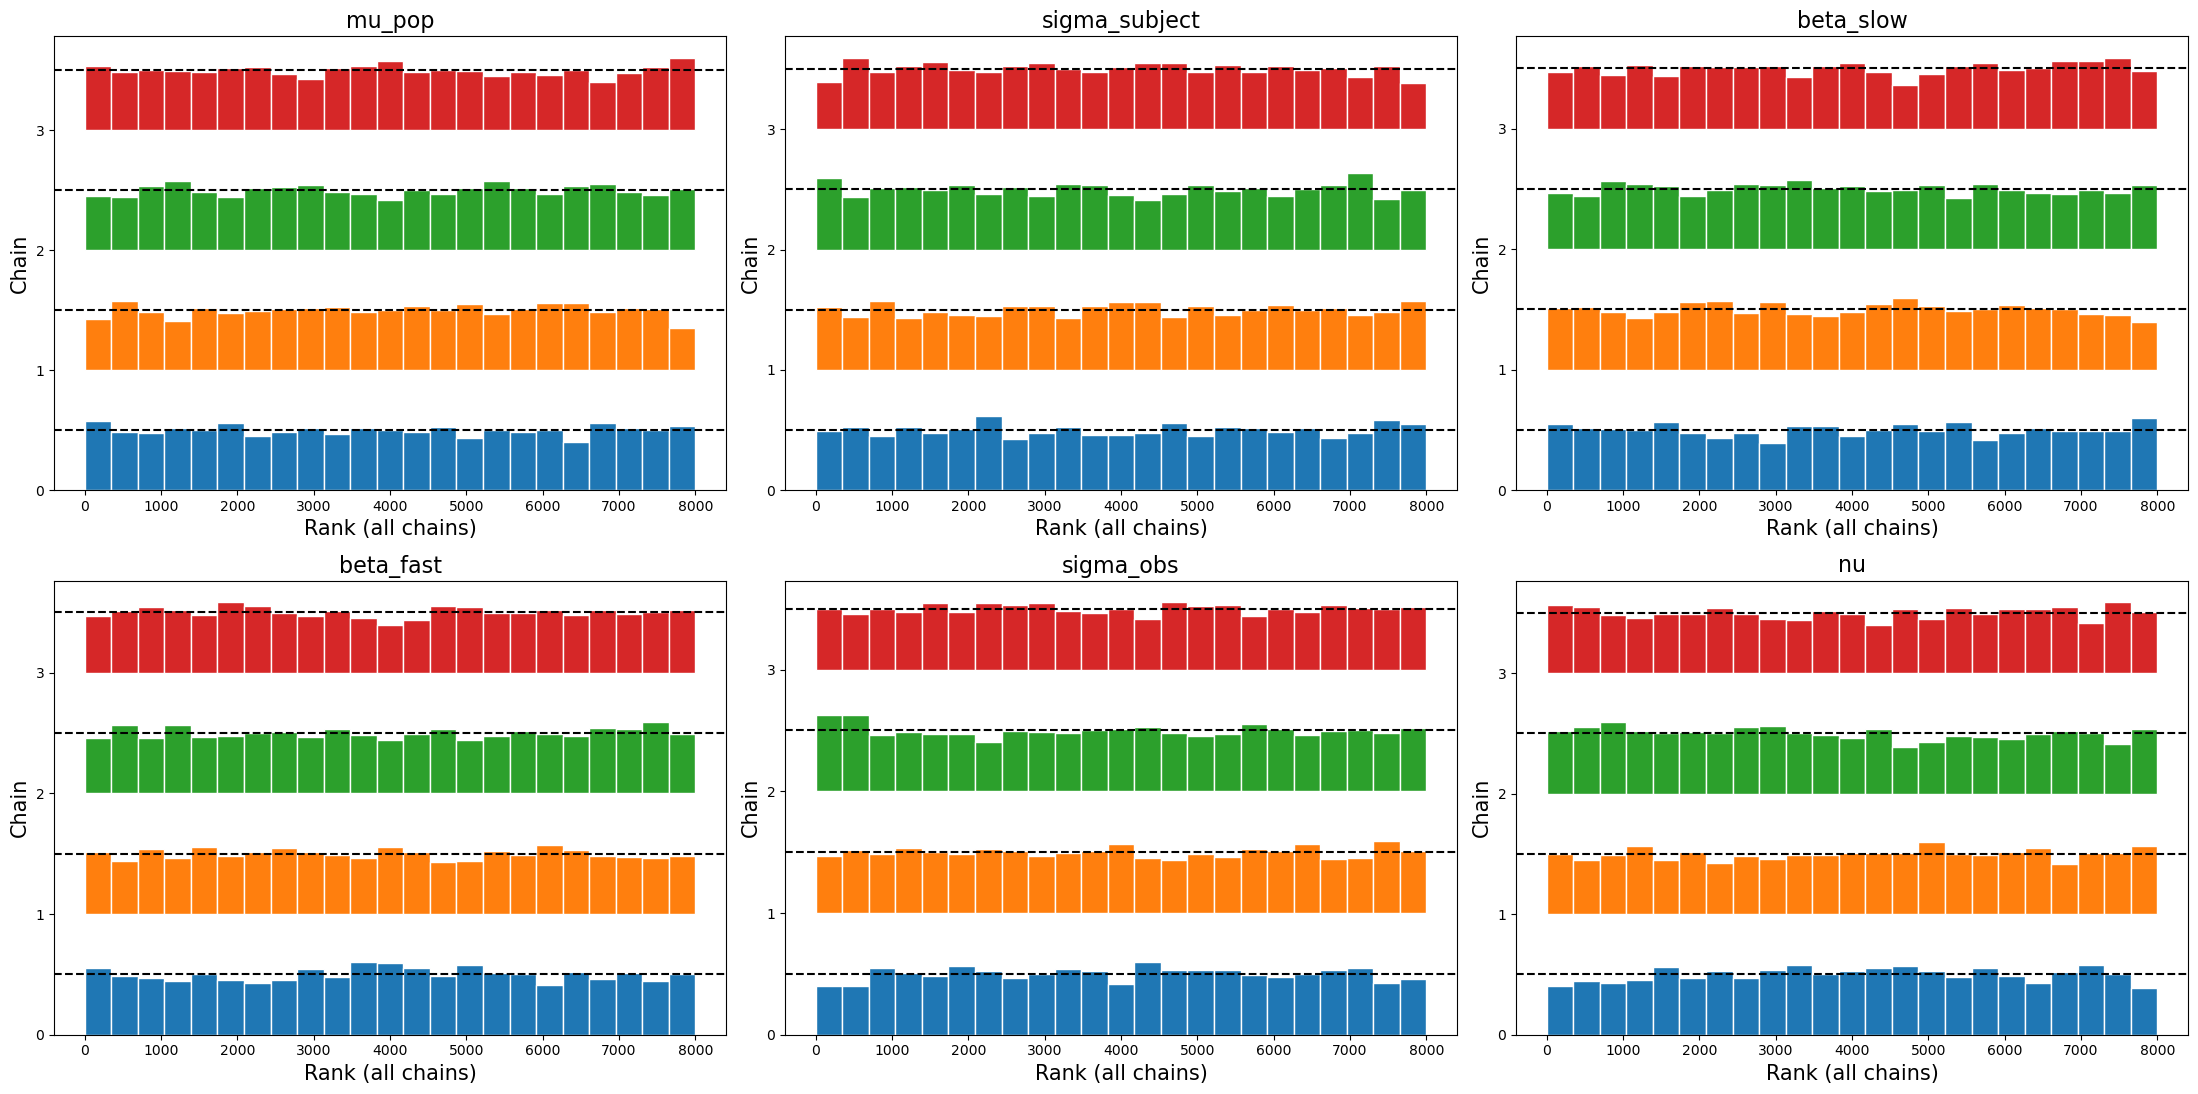

In [10]:
az.plot_rank(
    idata_model_2,
    var_names=["mu_pop", "sigma_subject", "beta_slow", "beta_fast", "sigma_obs", "nu"]
)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_2_rank.png", dpi=200, bbox_inches="tight")
plt.show()

## Subject-level intercepts

47 subject-specific intercepts, partially pooled toward `mu_pop`. The caterpillar plot orders subjects by posterior mean. Look for:
- How much spread is there between subjects? (should be around `sigma_subject` = 2.17)
- Do any subjects' 95% HDIs not overlap `mu_pop`? Those are subjects with detectable individual bias.
- Are subjects 08 and 47 (the "noisy" ones from EDA) at the extremes? If yes, their means are extreme. If no, their means are normal and it's their trial-level variance that's weird.

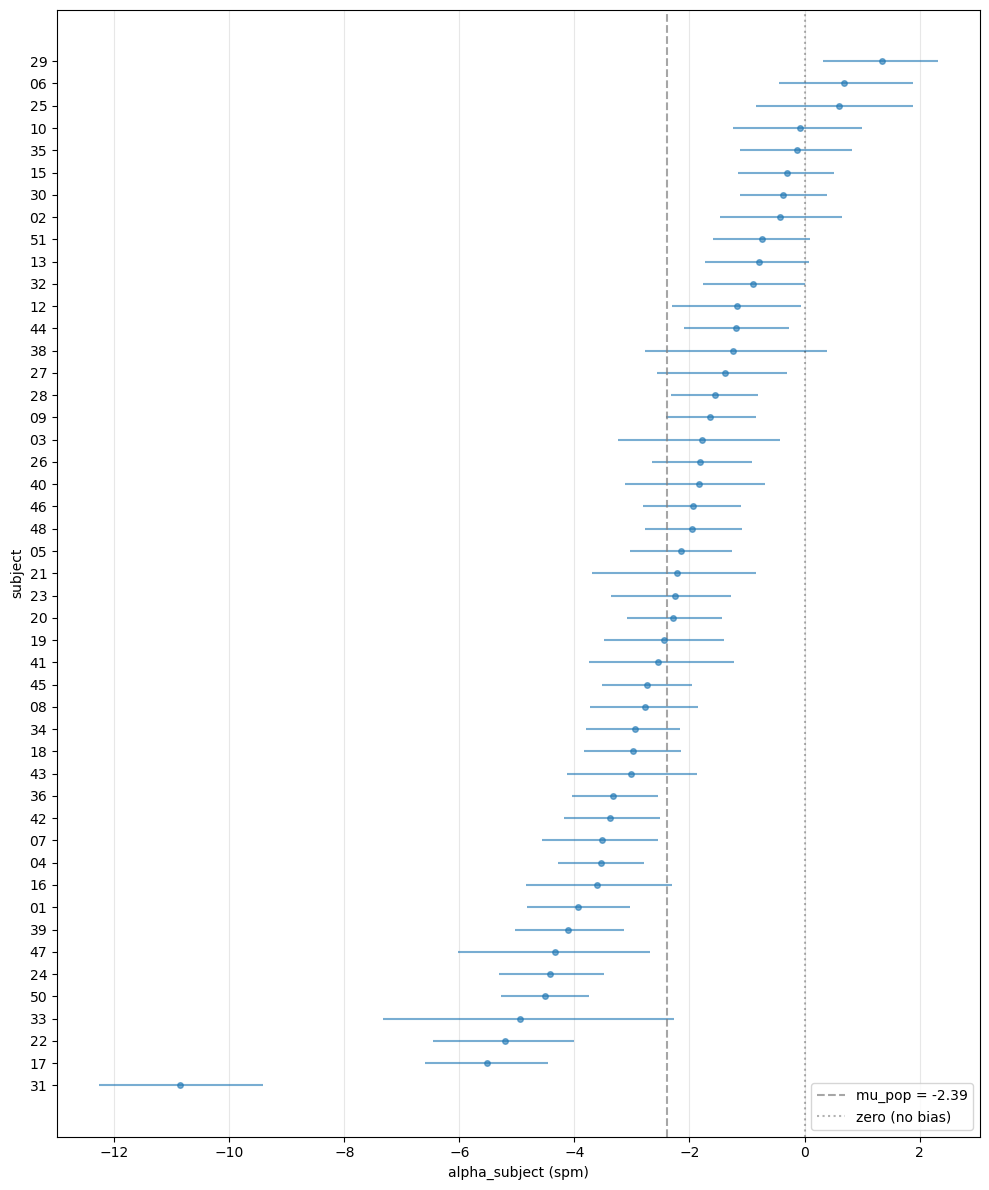


mu_pop posterior mean: -2.39
Subject range (posterior means): -10.86 to 1.35
Spread of subject posterior means: 2.04


In [11]:
# Caterpillar plot of subject intercepts, sorted by posterior mean
alpha_summary = az.summary(
    idata_model_2,
    var_names=['alpha_subject'],
    hdi_prob=0.95
).round(3)

# Extract subject labels from the index like 'alpha_subject[01]' -> '01'
alpha_summary['subject'] = [s.split('[')[1].rstrip(']') for s in alpha_summary.index]
alpha_summary_sorted = alpha_summary.sort_values('mean').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 12))
y_positions = np.arange(len(alpha_summary_sorted))
ax.errorbar(
    alpha_summary_sorted['mean'],
    y_positions,
    xerr=[alpha_summary_sorted['mean'] - alpha_summary_sorted['hdi_2.5%'],
          alpha_summary_sorted['hdi_97.5%'] - alpha_summary_sorted['mean']],
    fmt='o',
    color='C0',
    ecolor='C0',
    alpha=0.6,
    markersize=4,
)

# Reference line at mu_pop
mu_pop_mean = idata_model_2.posterior['mu_pop'].mean().values
ax.axvline(mu_pop_mean, ls='--', color='grey', alpha=0.7, label=f'mu_pop = {mu_pop_mean:.2f}')
ax.axvline(0, ls=':', color='black', alpha=0.3, label='zero (no bias)')

ax.set_yticks(y_positions)
ax.set_yticklabels(alpha_summary_sorted['subject'])
ax.set_xlabel('alpha_subject (spm)')
ax.set_ylabel('subject')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}model_2_alpha_subject_caterpillar.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nmu_pop posterior mean: {mu_pop_mean:.2f}")
print(f"Subject range (posterior means): {alpha_summary['mean'].min():.2f} to {alpha_summary['mean'].max():.2f}")
print(f"Spread of subject posterior means: {alpha_summary['mean'].std():.2f}")

Most subjects cluster near mu_pop = -2.39. HDIs overlap mu_pop AND zero. Indistinguishable from the grand mean.

Real outliers:
- Subject 31: -10.8 spm. HDI [-12.2, -9.5]. Not even close to mu_pop. Real individual bias.
- Subjects 17, 22: -5 to -5.5 spm. HDIs exclude zero. Detectable bias.
- Subject 29 at top: +1.3 spm. HDI barely excludes zero. Slight overcount.

Subjects 08 and 47 (EDA Finding 6 troublemakers):
- 08 sits at -2.6. Dead center. Nothing unusual about their mean bias.
- 47 at -4.3. Below average but HDI is wide, not exceptional.

Confirms what the hyperparameters said. The fat tails are NOT about those two subjects being biased on average. Subjects 08 and 47 have specific trials where the algorithm breaks, not systematic per-trial bias. The audit signal (133-trial undercount band) is trial-level, not subject-level.

Subject 31 is new. They weren't in the EDA findings carried forward. Worth investigating in the writeup. Possible explanations: unusual gait, extreme anthropometric, equipment calibration issue specific to that recording. Flag but don't chase now.

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_84843/333547988.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(f"{OUTPUT_PATH}model_2_ppc.png", dpi=200, bbox_inches="tight")
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


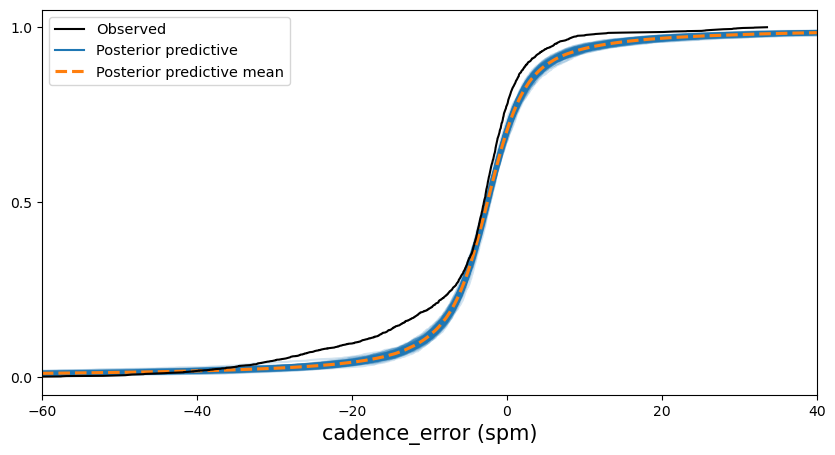

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_model_2, kind="cumulative", num_pp_samples=200, ax=ax)
ax.set_xlabel("cadence_error (spm)")
ax.set_xlim(-60, 40)
fig.savefig(f"{OUTPUT_PATH}model_2_ppc.png", dpi=200, bbox_inches="tight")
plt.show()

### PPC: fail, same pattern as Model 1-t

Asymmetric. Observed above the band on both sides.
- Left: data has way more mass in the -20 to -40 region than the model predicts.
- Right: model's right tail overshoots past where the data stops.

This looks essentially identical to Model 1-t. Adding 47 subject intercepts bought nothing for the distribution shape.

What this confirms: the fat-tail / asymmetry is trial-level, not subject-level. Model 2's hyperparameters said this (nu stayed at 1.11, sigma_obs only dropped from 3.22 to 2.75). The PPC confirms it visually.

Model 2b (per-subject sigma_obs) is triggered on per-subject coverage failure, but the issue here is cohort-level. Skipping.

Moving to Model 3. If sex explains any of the left-tail mass, that would show up as beta_sex absorbing it.

In [13]:
idata_model_1 = az.from_netcdf("../data/processed/idata_model_1.nc")
idata_model_1t = az.from_netcdf("../data/processed/idata_model_1t.nc")

In [14]:
comparison = az.compare(
    {
        "Model 1 (Normal)": idata_model_1,
        "Model 1-t (Student-t)": idata_model_1t,
        "Model 2 (Student-t + subject)": idata_model_2,
    },
    ic="loo"
)
print(comparison)

/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


                               rank      elpd_loo      p_loo    elpd_diff  \
Model 2 (Student-t + subject)     0  -9561.812920  55.883230     0.000000   
Model 1-t (Student-t)             1  -9797.784971   4.506263   235.972051   
Model 1 (Normal)                  2 -10669.754559   6.524155  1107.941639   

                                     weight         se        dse  warning  \
Model 2 (Student-t + subject)  8.959947e-01  81.203939   0.000000     True   
Model 1-t (Student-t)          1.963511e-11  78.656602  21.549289    False   
Model 1 (Normal)               1.040053e-01  70.340772  55.632752    False   

                              scale  
Model 2 (Student-t + subject)   log  
Model 1-t (Student-t)           log  
Model 1 (Normal)                log  


In [15]:
# Check which observations have bad Pareto k, if any
loo_m2 = az.loo(idata_model_2, pointwise=True)
print(loo_m2)
print()
print(f"Number of observations with k > 0.7: {(loo_m2.pareto_k > 0.7).sum()}")
print(f"Number of observations with k > 1.0: {(loo_m2.pareto_k > 1.0).sum()}")

/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 2781 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -9561.81    81.20
p_loo       55.88        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2759   99.2%
   (0.70, 1]   (bad)         6    0.2%
   (1, Inf)   (very bad)   16    0.6%


Number of observations with k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(22)
Number of observations with k > 1.0: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(16)


In [16]:
# Identify which trials have bad Pareto k
pareto_k = loo_m2.pareto_k.values  # flatten to numpy
bad_idx = np.where(pareto_k > 0.7)[0]
print(f"n trials with k > 0.7: {len(bad_idx)}")
print(f"n trials with k > 1.0: {(pareto_k > 1.0).sum()}")

# Look up what those trials are
bad_trials = df.iloc[bad_idx][['subject_id', 'sex', 'speed', 'cadence_error']].copy()
bad_trials['pareto_k'] = pareto_k[bad_idx]
bad_trials = bad_trials.sort_values('pareto_k', ascending=False)
print()
print(bad_trials.to_string())

# Summary by subject and speed
print()
print("By subject:")
print(bad_trials['subject_id'].value_counts())
print()
print("By speed:")
print(bad_trials['speed'].value_counts())
print()
print("By sex:")
print(bad_trials['sex'].value_counts())

n trials with k > 0.7: 22
n trials with k > 1.0: 16

     subject_id sex speed  cadence_error  pareto_k
2610         47   F  comf      -4.876056  1.290969
2621         47   F  fast      -5.802234  1.225834
2592         47   F  fast      -5.989100  1.223213
2584         47   F  fast      -5.641169  1.161807
2574         47   F  comf      -2.689514  1.137968
2607         47   F  comf      -2.739687  1.137653
2576         47   F  comf      -2.447164  1.135983
2616         47   F  fast      -7.091387  1.132834
2608         47   F  comf      -1.488213  1.091132
2613         47   F  comf      -1.483514  1.090165
2585         47   F  fast      -5.082495  1.065101
2620         47   F  fast      -3.598848  1.020003
2593         47   F  fast      -4.021912  1.014821
2611         47   F  comf       0.672538  1.010765
2590         47   F  fast      -4.409483  1.008628
2586         47   F  fast      -1.746186  1.002404
2589         47   F  fast      -2.604704  0.993861
2600         47   F  slow    

All 22 bad-k trials belong to subject 47. Not 08 or 47 together, just 47.

Reading subject 47's trial pattern:
- Most trials in the -3 to -7 range (moderate undercounting).
- Three comf trials at +16, +15, +25 spm. Wild IMU overcount on those specific trials.
- Their alpha_subject posterior is sensitive to these trials individually, so LOO importance sampling fails.

What this says about subject 47: their problem isn't systematic undercount, it's erratic behavior. Some trials the IMU badly undercounts, some trials it badly overcounts. The subject intercept averages to -4.3 (middle of the pack) because the errors cancel.

This doesn't change the Model 2 > Model 1-t ranking. elpd_diff is 236 vs dse 21; even if all 22 contributions are wrong, the conclusion stands. Noting as a limitation finding.

az.reloo would recover exact LOO for the bad-k trials but it's slow and this isn't a decision point. Moving on.

## Per-subject PPC tail coverage

MODEL_SPEC defines a trigger for Model 2b: any subject with tail coverage below 80% while cohort median is above 90%. Compute per-subject coverage from the posterior predictive draws.

"Tail coverage" = fraction of each subject's observed trials falling inside the 95% posterior predictive interval for that trial.

Cohort median coverage: 0.967
Cohort mean coverage:   0.947

Subjects with coverage < 0.80:
subject_id  n_trials  coverage
        47        60  0.733333
        08        60  0.733333

n subjects with coverage < 0.80: 2
n subjects with coverage < 0.90: 8


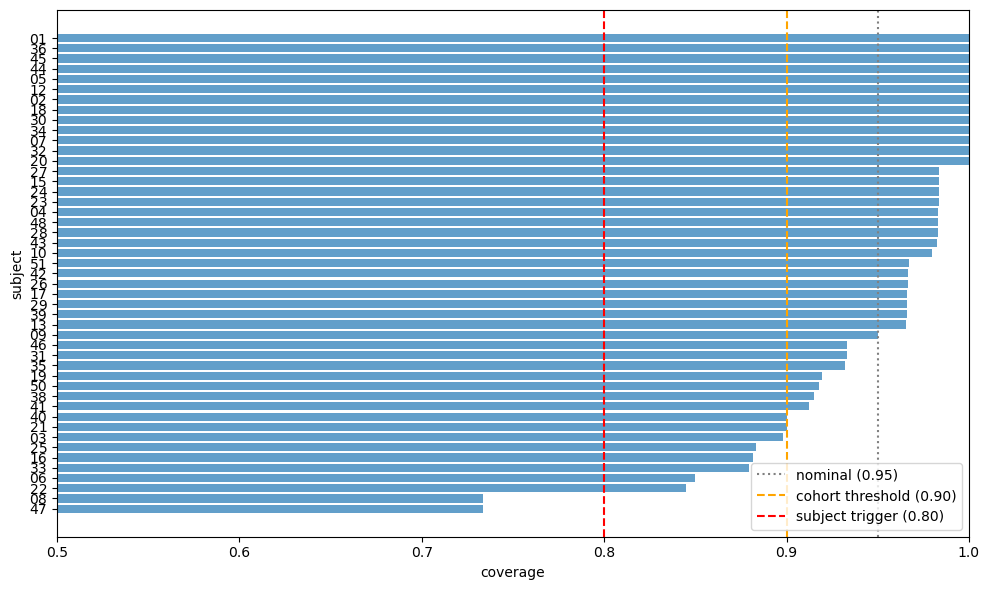

In [17]:
# Per-subject PPC tail coverage
# For each trial, compute the 95% posterior predictive interval.
# Then ask: what fraction of each subject's trials fell inside?

pp_samples = idata_model_2.posterior_predictive['likelihood'].stack(sample=('chain', 'draw')).values
# Shape: (n_trials, n_samples)

# 95% interval per trial (across posterior predictive samples)
pp_lower = np.percentile(pp_samples, 2.5, axis=1)
pp_upper = np.percentile(pp_samples, 97.5, axis=1)

# Which trials fell inside?
inside = (cadence_error >= pp_lower) & (cadence_error <= pp_upper)

# Per-subject coverage
coverage_df = pd.DataFrame({
    'subject_id': df['subject_id'].values,
    'inside': inside,
})
per_subject = coverage_df.groupby('subject_id').agg(
    n_trials=('inside', 'size'),
    coverage=('inside', 'mean'),
).reset_index()
per_subject = per_subject.sort_values('coverage')

print(f"Cohort median coverage: {per_subject['coverage'].median():.3f}")
print(f"Cohort mean coverage:   {per_subject['coverage'].mean():.3f}")
print()
print("Subjects with coverage < 0.80:")
bad_cov = per_subject[per_subject['coverage'] < 0.80]
print(bad_cov.to_string(index=False))
print()
print(f"n subjects with coverage < 0.80: {len(bad_cov)}")
print(f"n subjects with coverage < 0.90: {(per_subject['coverage'] < 0.90).sum()}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
per_subject_plot = per_subject.sort_values('coverage').reset_index(drop=True)
ax.barh(per_subject_plot['subject_id'], per_subject_plot['coverage'], color='C0', alpha=0.7)
ax.axvline(0.95, ls=':', color='grey', label='nominal (0.95)')
ax.axvline(0.90, ls='--', color='orange', label='cohort threshold (0.90)')
ax.axvline(0.80, ls='--', color='red', label='subject trigger (0.80)')
ax.set_xlabel('coverage')
ax.set_ylabel('subject')
ax.set_xlim(0.5, 1.0)
ax.legend()
plt.tight_layout()
fig.savefig(f"{OUTPUT_PATH}model_2_per_subject_ppc.png", dpi=200, bbox_inches="tight")
plt.show()

Trigger fires.

- Cohort median coverage 0.967, mean 0.947. Most subjects are fine.
- Two subjects below the 0.80 trigger: 47 and 08, both at 73.3%.
- Eight subjects below 0.90 overall.

Confirms the cohort-level PPC was being dragged by two specific subjects rather than a distributional problem. The cohort miscoverage isn't cohort-wide; it's concentrated. Model 2b fits.

Also: this reframes what the audit finding probably is. "Some subjects' trials go off a cliff" is more precise than "the algorithm has fat tails." 2/47 is ~4% of subjects generating most of the tail mass.

## Model 2a and 2b: per-subject sigma_obs

Two variants to fit and compare:

- **Model 2a**: Normal likelihood + per-subject `sigma_obs[s]`. Tests whether per-subject scales alone can fix the tail miscoverage, making Student-t unnecessary.
- **Model 2b**: Student-t likelihood + per-subject `sigma_obs[s]`. Keeps both. Maximal model.

LOO-CV across {Model 2, 2a, 2b} will tell us which pieces are pulling weight.

### Shared structure

Both variants keep Model 2's subject intercepts `alpha_subject` and hyperparameters `mu_pop`, `sigma_subject`. The only change is `sigma_obs` goes from scalar to per-subject vector with its own hyperprior `sigma_obs_scale`.

- `sigma_obs[s]    ~ HalfNormal(sigma_obs_scale)   for s = 1..47`
- `sigma_obs_scale ~ HalfNormal(10)`

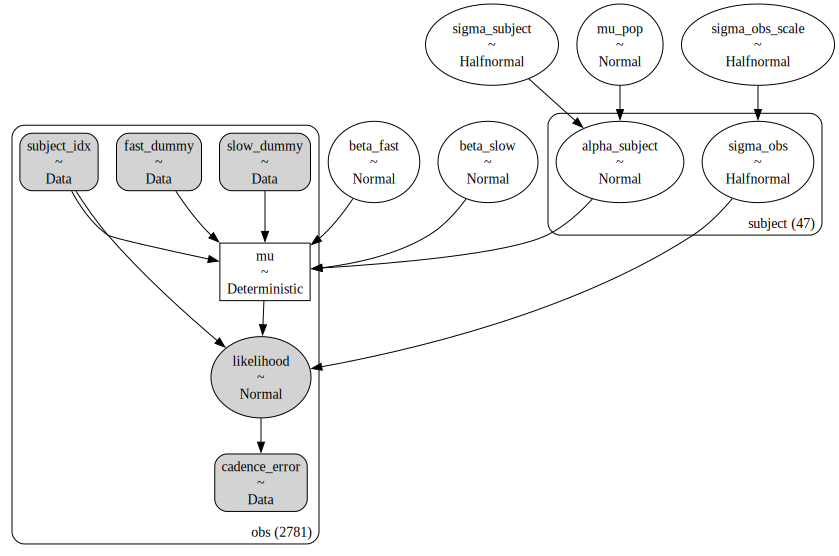

In [18]:
# Model 2a: Normal likelihood, per-subject sigma_obs

with pm.Model(coords=coords) as model_2a:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    # population hyperpriors for subject intercepts
    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)

    # subject intercepts (same as Model 2)
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=mu_pop,
        sigma=sigma_subject,
        dims='subject'
    )

    # per-subject observation scales — this is what's new
    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    # fixed effects
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood — Normal, with per-subject sigma_obs[s]
    pm.Normal('likelihood', mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_2a)
_dag.render(f"{OUTPUT_PATH}model_2a_dag", format="png", cleanup=True)
_dag

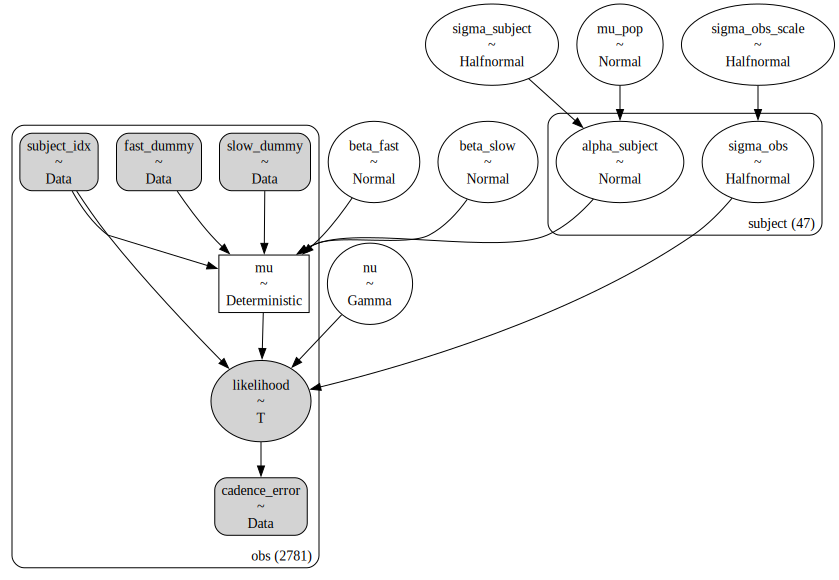

In [19]:
# Model 2b: Student-t likelihood, per-subject sigma_obs

with pm.Model(coords=coords) as model_2b:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    # population hyperpriors for subject intercepts
    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)

    # subject intercepts
    alpha_subject = pm.Normal(
        'alpha_subject',
        mu=mu_pop,
        sigma=sigma_subject,
        dims='subject'
    )

    # per-subject observation scales
    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    # student-t shape and fixed effects
    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood — Student-t with per-subject sigma_obs[s]
    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_2b)
_dag.render(f"{OUTPUT_PATH}model_2b_dag", format="png", cleanup=True)
_dag

In [20]:
with model_2a:
    idata_model_2a = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_2a,
        extend_inferencedata=True,
        random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.
Sampling: [likelihood]


Output()

In [21]:
with model_2b:
    idata_model_2b = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_2b,
        extend_inferencedata=True,
        random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.
Sampling: [likelihood]


Output()

## Diagnostics: Model 2a and 2b

Top-level parameters only. Per-subject `alpha_subject` and `sigma_obs` get checked separately since they're 47-vectors.

In [22]:
print("Model 2a (Normal + per-subject sigma):")
az.summary(
    idata_model_2a,
    var_names=["mu_pop", "sigma_subject", "sigma_obs_scale", "beta_slow", "beta_fast"],
    hdi_prob=0.95
).round(3)

Model 2a (Normal + per-subject sigma):


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,-5.006,0.745,-6.538,-3.631,0.008,0.008,8711.0,6225.0,1.0
sigma_subject,4.824,0.572,3.806,5.996,0.006,0.007,8934.0,6575.0,1.0
sigma_obs_scale,10.381,1.083,8.320,12.485,0.009,0.015,14773.0,4482.0,1.0
beta_slow,0.850,0.325,0.222,1.479,0.005,0.003,3660.0,4881.0,1.0
beta_fast,-1.840,0.317,-2.469,-1.224,0.005,0.003,4211.0,5607.0,1.0


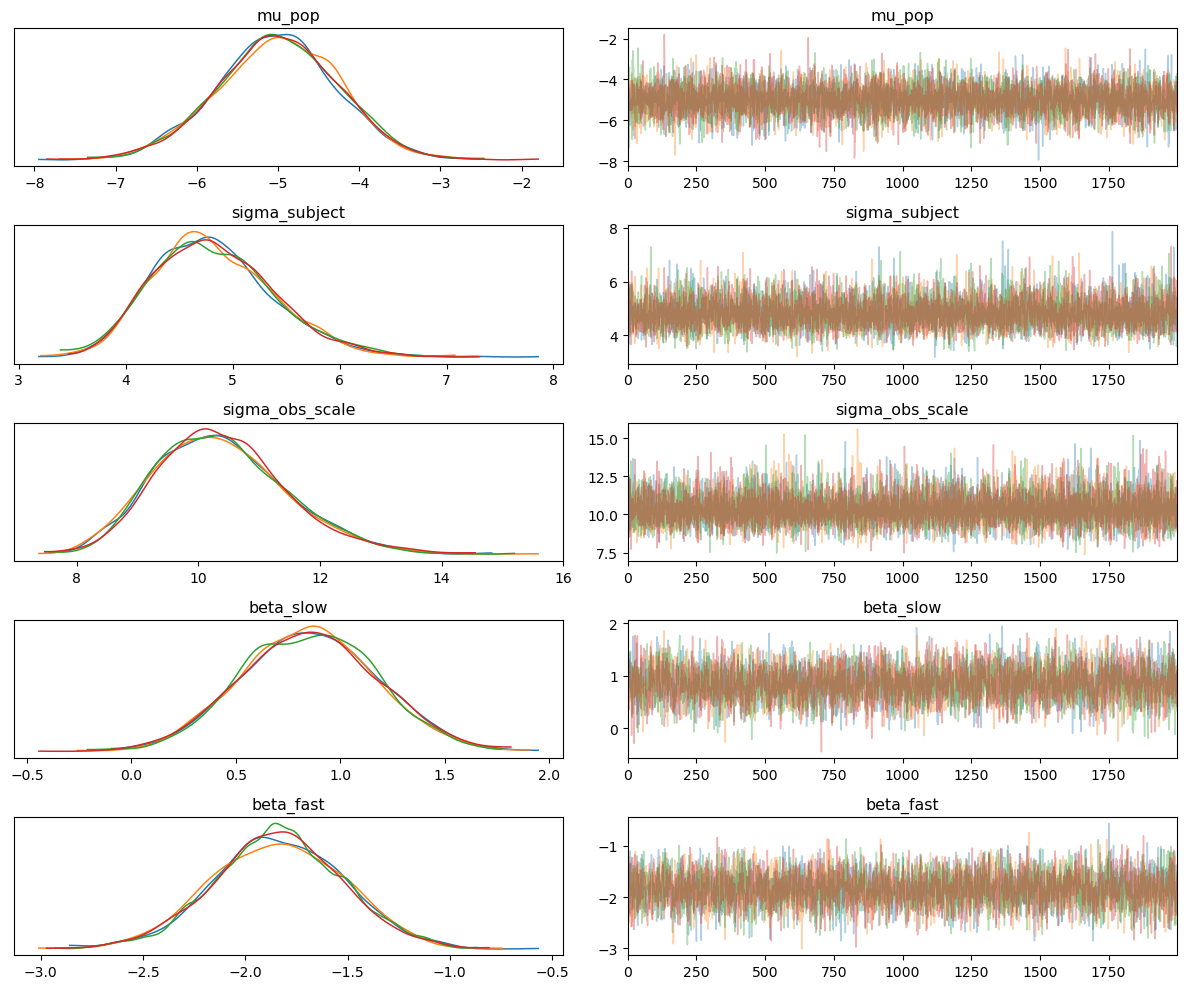

In [23]:
az.plot_trace(
    idata_model_2a,
    var_names=["mu_pop", "sigma_subject", "sigma_obs_scale", "beta_slow", "beta_fast"],
    compact=False
)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_2a_trace.png", dpi=200, bbox_inches="tight")
plt.show()

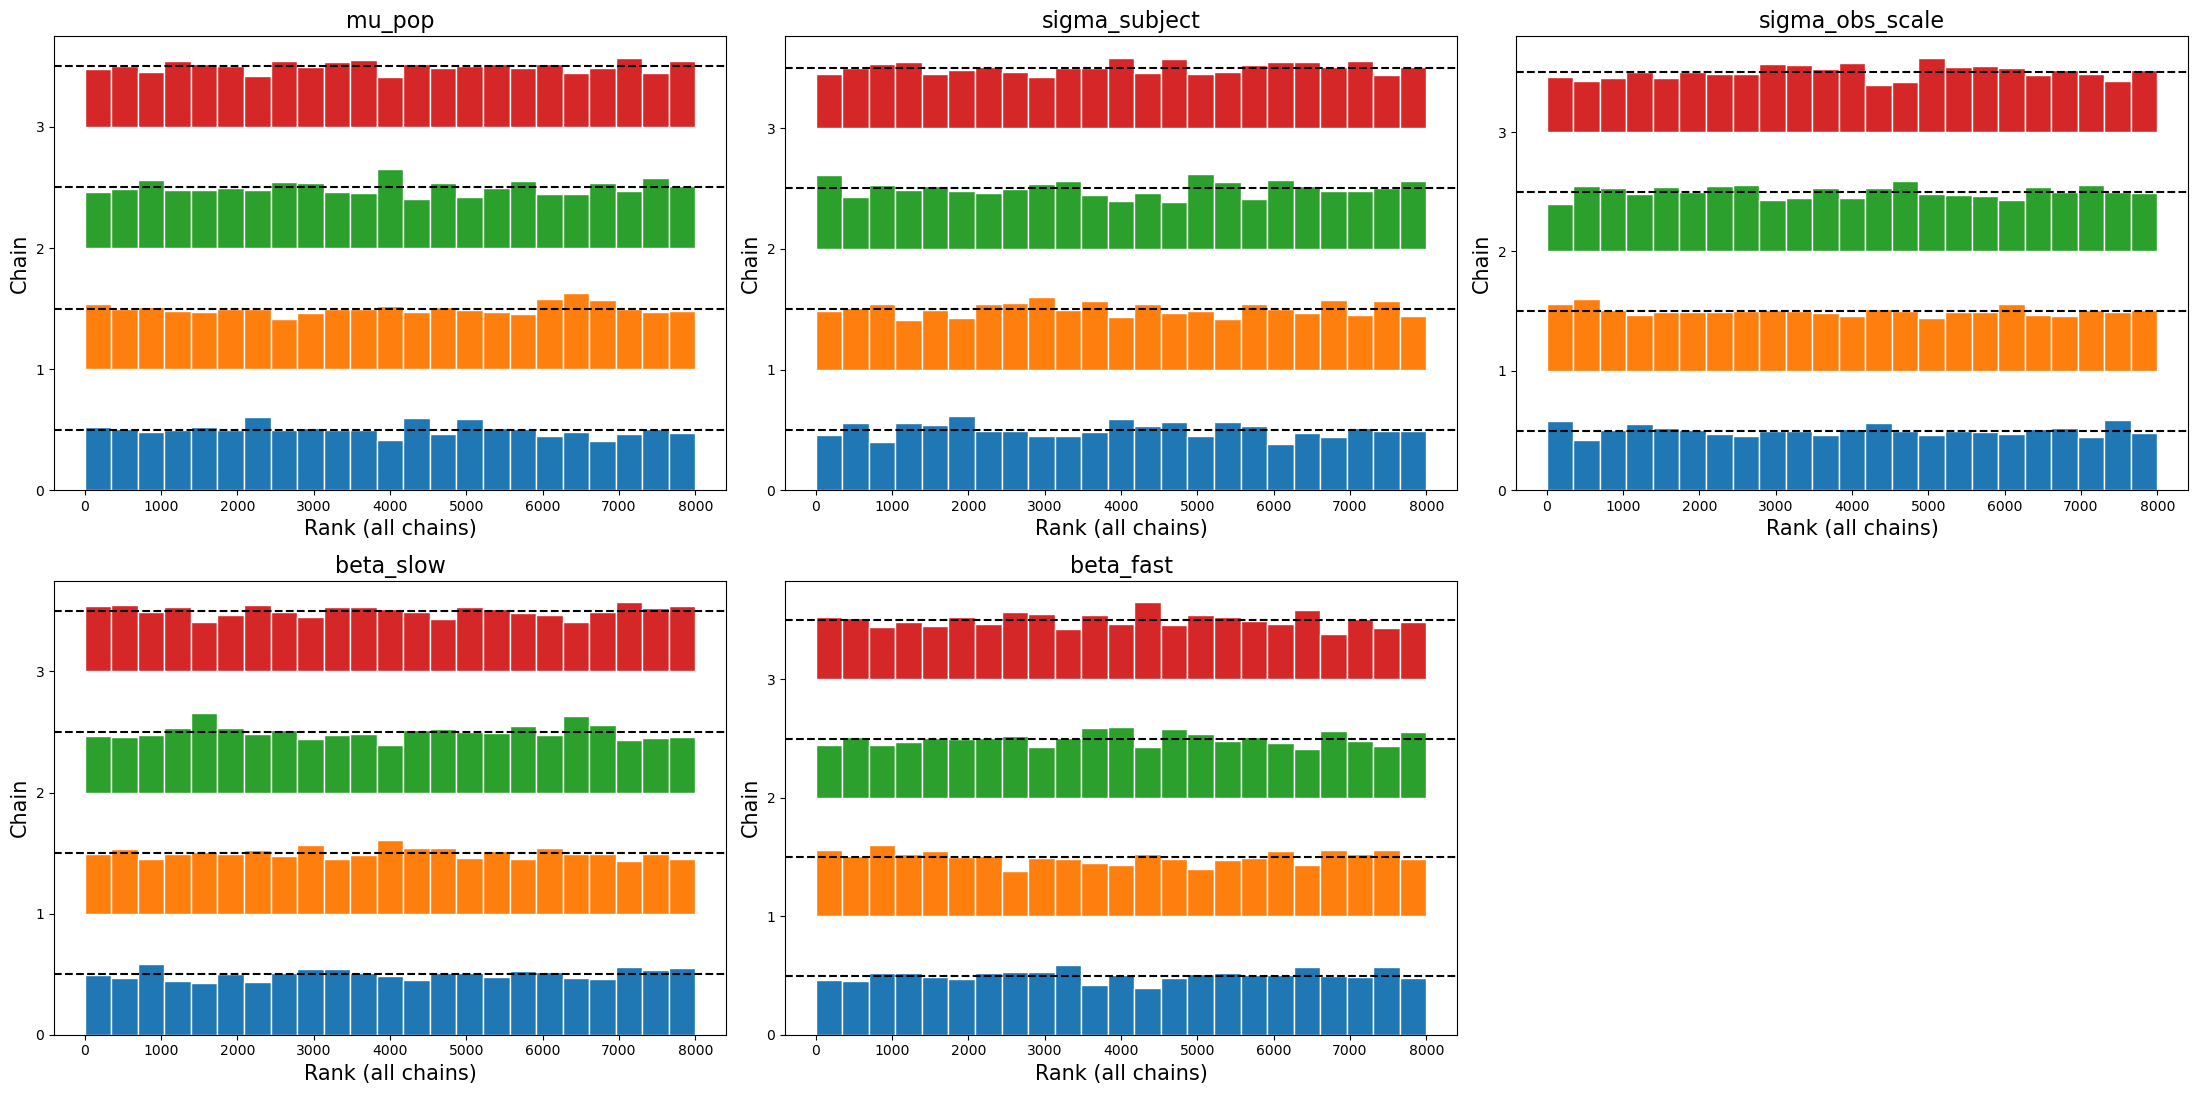

In [24]:
az.plot_rank(
    idata_model_2a,
    var_names=["mu_pop", "sigma_subject", "sigma_obs_scale", "beta_slow", "beta_fast"]
)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_2a_rank.png", dpi=200, bbox_inches="tight")
plt.show()

In [25]:
print("Model 2b (Student-t + per-subject sigma):")
az.summary(
    idata_model_2b,
    var_names=["mu_pop", "sigma_subject", "sigma_obs_scale", "beta_slow", "beta_fast", "nu"],
    hdi_prob=0.95
).round(3)

Model 2b (Student-t + per-subject sigma):


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,-3.247,0.463,-4.190,-2.364,0.005,0.005,8848.0,6421.0,1.0
sigma_subject,2.966,0.387,2.229,3.722,0.005,0.004,6781.0,7140.0,1.0
sigma_obs_scale,5.256,0.587,4.175,6.429,0.006,0.007,8620.0,6010.0,1.0
beta_slow,1.035,0.172,0.690,1.372,0.003,0.002,4305.0,6227.0,1.0
beta_fast,-1.224,0.173,-1.577,-0.908,0.003,0.002,4329.0,5465.0,1.0
nu,1.689,0.084,1.523,1.846,0.001,0.001,4462.0,5976.0,1.0


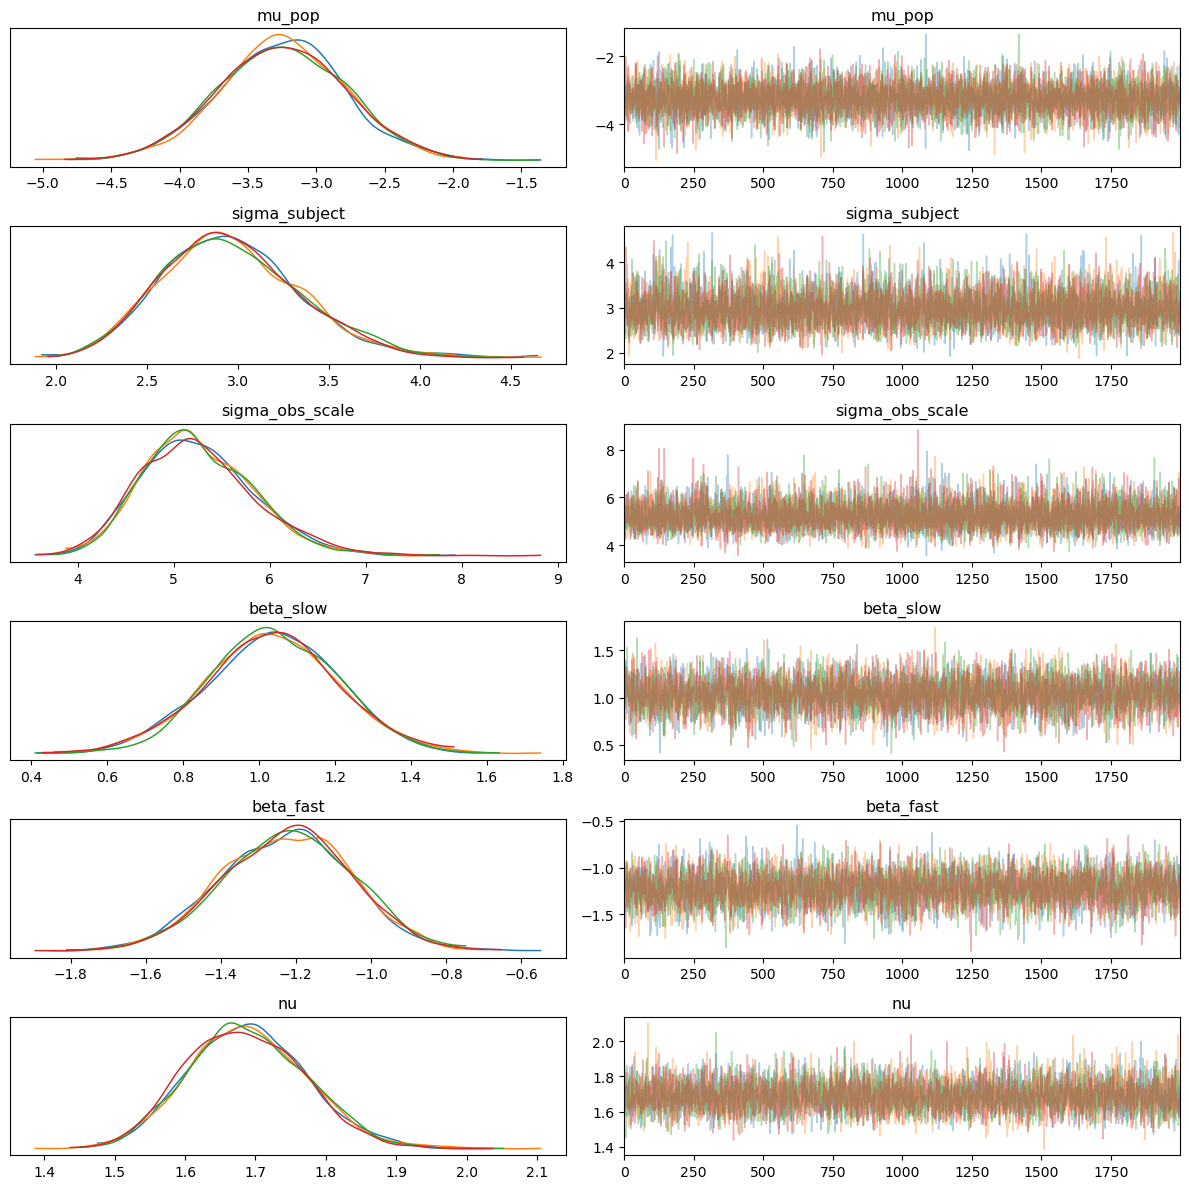

In [26]:
az.plot_trace(
    idata_model_2b,
    var_names=["mu_pop", "sigma_subject", "sigma_obs_scale", "beta_slow", "beta_fast", "nu"],
    compact=False
)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_2b_trace.png", dpi=200, bbox_inches="tight")
plt.show()

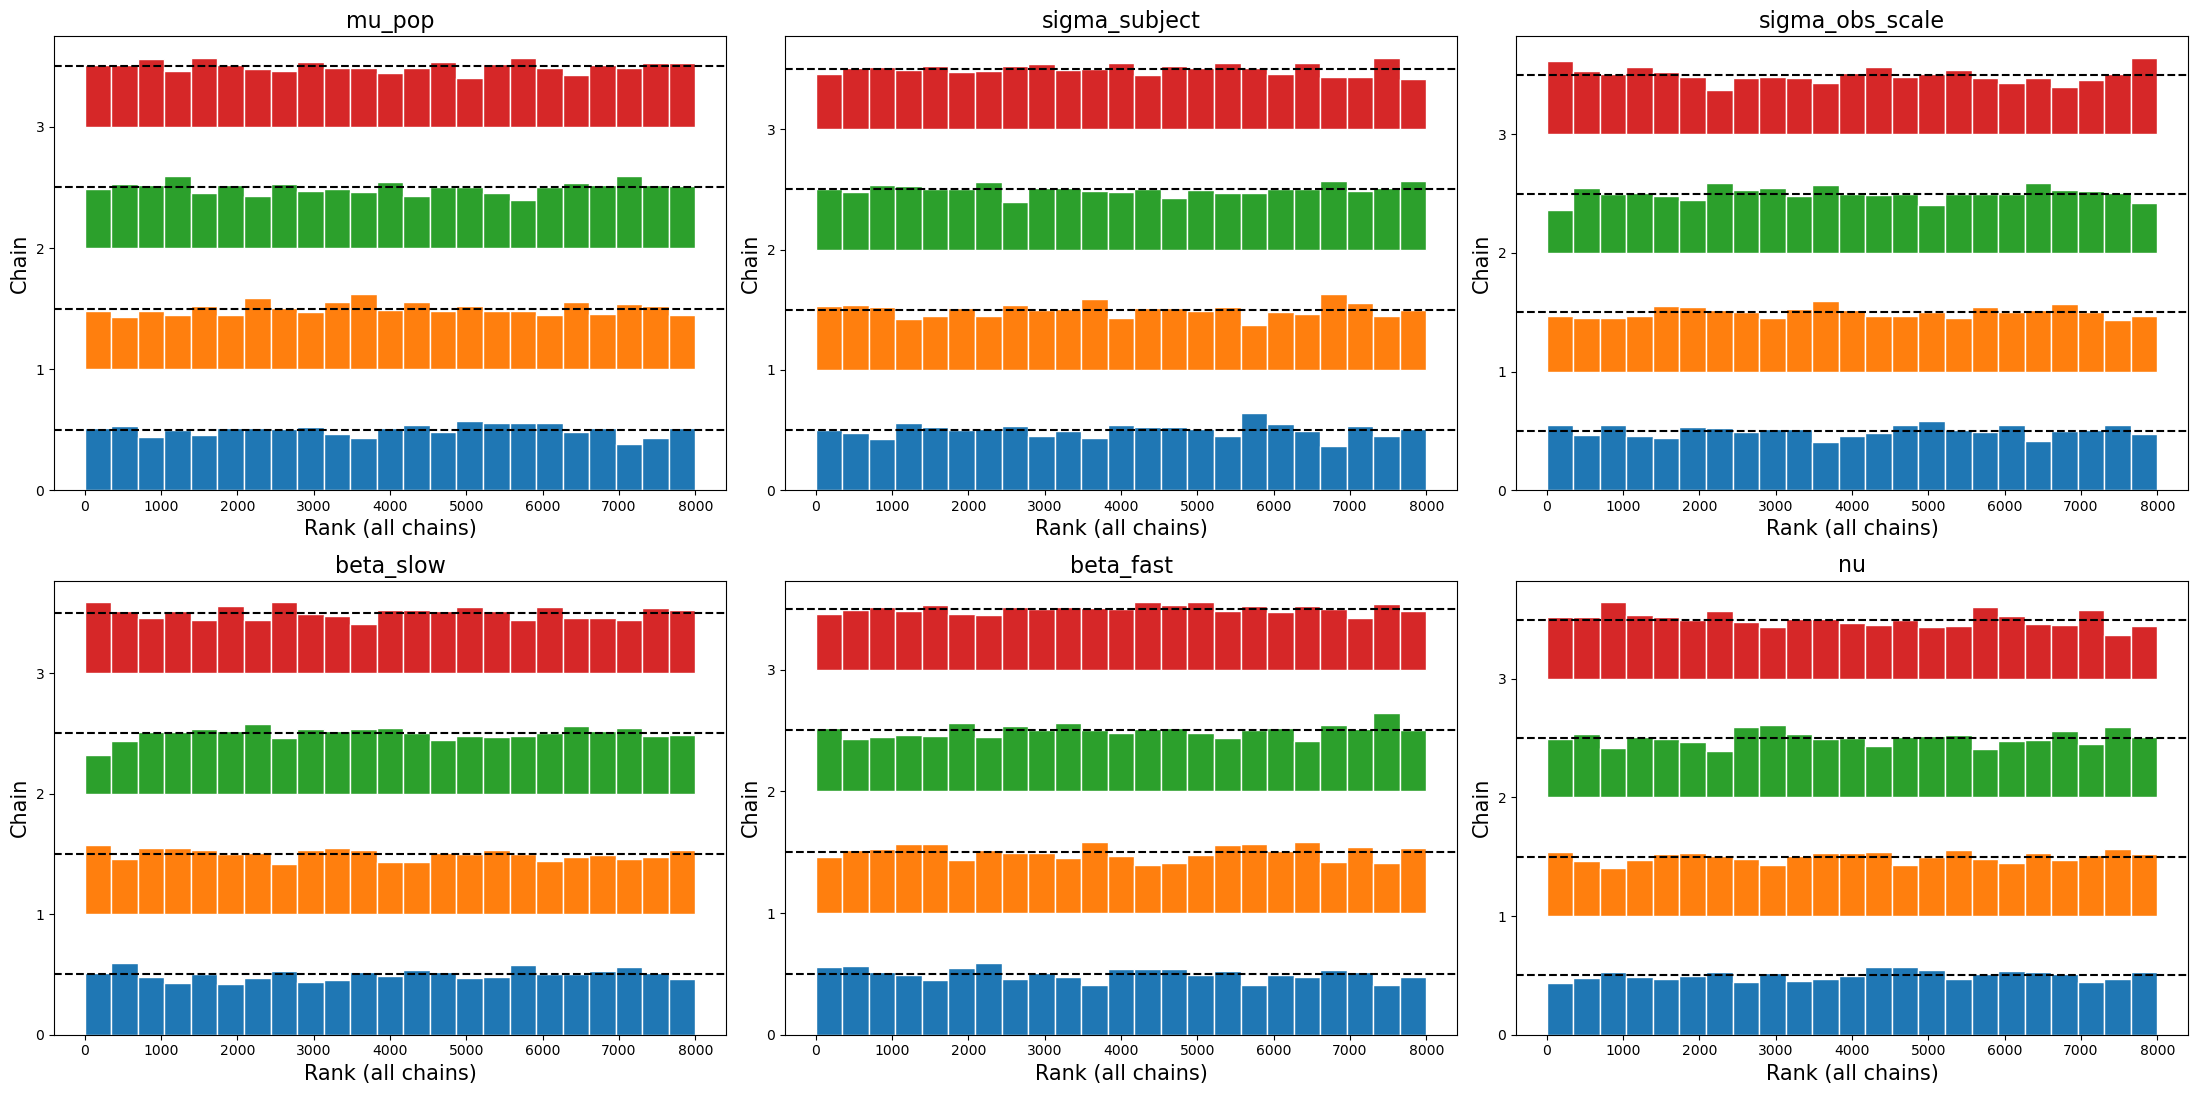

In [27]:
az.plot_rank(
    idata_model_2b,
    var_names=["mu_pop", "sigma_subject", "sigma_obs_scale", "beta_slow", "beta_fast", "nu"]
)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_2b_rank.png", dpi=200, bbox_inches="tight")
plt.show()

In [28]:
comparison = az.compare(
    {
        "Model 2 (Student-t, cohort sigma)": idata_model_2,
        "Model 2a (Normal, per-subject sigma)": idata_model_2a,
        "Model 2b (Student-t, per-subject sigma)": idata_model_2b,
    },
    ic="loo"
)
print(comparison)

/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  war

                                         rank      elpd_loo       p_loo  \
Model 2b (Student-t, per-subject sigma)     0  -9306.649586  103.336079   
Model 2 (Student-t, cohort sigma)           1  -9561.812920   55.883230   
Model 2a (Normal, per-subject sigma)        2 -10043.060577  228.619365   

                                          elpd_diff    weight         se  \
Model 2b (Student-t, per-subject sigma)    0.000000  0.624259  75.897090   
Model 2 (Student-t, cohort sigma)        255.163334  0.219798  81.203939   
Model 2a (Normal, per-subject sigma)     736.410992  0.155943  97.867504   

                                               dse  warning scale  
Model 2b (Student-t, per-subject sigma)   0.000000    False   log  
Model 2 (Student-t, cohort sigma)        30.164568     True   log  
Model 2a (Normal, per-subject sigma)     72.135120     True   log  


### LOO three-way result

Rank:
1. Model 2b (Student-t + per-subject sigma) — winner, no Pareto-k warning
2. Model 2 (Student-t + cohort sigma) — 255 behind, warning
3. Model 2a (Normal + per-subject sigma) — 736 behind, warning

The hypothesis test was clean.

- Swap Student-t for per-subject Normal (2 -> 2a): elpd drops 481. Per-subject sigma alone is NOT a substitute for fat tails.
- Keep Student-t, add per-subject sigma (2 -> 2b): elpd improves 255. Per-subject sigma adds real value on top of Student-t.
- Both necessary. Neither sufficient.

p_loo tells the overfitting story:
- Model 2a: p_loo = 228 for a ~99-parameter model. Per-subject sigmas are being used to fit specific trials. Overfit.
- Model 2b: p_loo = 103 for a ~100-parameter model. Roughly matches actual complexity. Clean fit.

Subject 47 is no longer a Pareto-k problem under Model 2b. Per-subject sigma gives subject 47 their own noise scale, so their weird trials don't dominate a single shared sigma_obs. Their own sigma_obs is just wider than other subjects.

What the data has going on:
1. Between-subject mean differences (alpha_subject)
2. Between-subject noise differences (per-subject sigma_obs)
3. Within-subject outlier trials (Student-t nu)

All three are real. Model 2b has all three.

Decision: Model 2b is the Model 2 winner. Template for Models 3 and 4.

In [29]:
# Per-subject PPC coverage for Model 2b
pp_samples = idata_model_2b.posterior_predictive['likelihood'].stack(sample=('chain', 'draw')).values

pp_lower = np.percentile(pp_samples, 2.5, axis=1)
pp_upper = np.percentile(pp_samples, 97.5, axis=1)
inside = (cadence_error >= pp_lower) & (cadence_error <= pp_upper)

coverage_df = pd.DataFrame({
    'subject_id': df['subject_id'].values,
    'inside': inside,
})
per_subject = coverage_df.groupby('subject_id').agg(
    n_trials=('inside', 'size'),
    coverage=('inside', 'mean'),
).reset_index()

print(f"Model 2b cohort median coverage: {per_subject['coverage'].median():.3f}")
print(f"Model 2b cohort mean coverage:   {per_subject['coverage'].mean():.3f}")
print()
print("Worst 5 subjects:")
print(per_subject.nsmallest(5, 'coverage').to_string(index=False))
print()
print(f"n subjects with coverage < 0.80: {(per_subject['coverage'] < 0.80).sum()}")
print(f"n subjects with coverage < 0.90: {(per_subject['coverage'] < 0.90).sum()}")

Model 2b cohort median coverage: 0.966
Model 2b cohort mean coverage:   0.950

Worst 5 subjects:
subject_id  n_trials  coverage
        22        58  0.844828
        26        60  0.850000
        42        60  0.850000
        44        60  0.850000
        51        61  0.868852

n subjects with coverage < 0.80: 0
n subjects with coverage < 0.90: 8


### Per-subject PPC: Model 2b

- Cohort median 0.966, mean 0.950. Same as Model 2.
- Worst subject: 22 at 0.845. Subjects 47 and 08 (the original triggers) are no longer in the bottom.
- Zero subjects below 0.80. Trigger no longer fires.
- 8 subjects still below 0.90, same as Model 2. Per-subject sigma helped the extreme cases, not the marginal ones.

Per-subject sigma was a targeted fix. Worked on the two worst subjects. Didn't meaningfully change the merely-below-nominal subjects. That's fine — those weren't trigger cases.

Combined with LOO: Model 2b is the Model 2-series winner, convincingly.

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_84843/2927041276.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(f"{OUTPUT_PATH}model_2b_ppc.png", dpi=200, bbox_inches="tight")
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


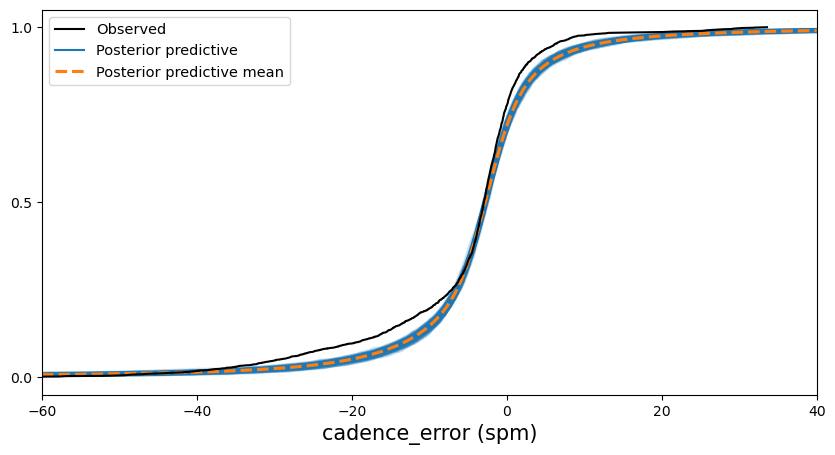

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_model_2b, kind="cumulative", num_pp_samples=200, ax=ax)
ax.set_xlabel("cadence_error (spm)")
ax.set_xlim(-60, 40)
fig.savefig(f"{OUTPUT_PATH}model_2b_ppc.png", dpi=200, bbox_inches="tight")
plt.show()

### PPC: Model 2b

Better than Model 2. Observed hugs the posterior predictive much more tightly through the center. Right-side overshoot is gone.

Residual: left-shoulder bump around -20 to -10. Smaller than Model 2's (maybe 5pp vs 10pp) but not zero.

Why this residual is consistent with what the other diagnostics said:
- 47 and 08 (the two most-miscovered subjects) are now fine because of their own wide sigmas.
- 8 subjects still below 0.90 coverage are collectively generating the remaining left shoulder.
- Student-t fixes symmetric kurtosis but not asymmetry. The left tail is longer than the right.

The residual miscoverage is asymmetry, which is exactly what Model 3 (sex) and Model 4 (anthropometrics) are designed to test structurally. Accept the residual, let the demographic models see if they can absorb it.

In [31]:
idata_model_2b.to_netcdf("../data/processed/idata_model_2b.nc")
# Also save 2 and 2a for the comparison notebook
idata_model_2.to_netcdf("../data/processed/idata_model_2.nc")
idata_model_2a.to_netcdf("../data/processed/idata_model_2a.nc")

az.summary(idata_model_2).to_csv(f"{OUTPUT_PATH}model_2_summary.csv")
az.summary(idata_model_2a).to_csv(f"{OUTPUT_PATH}model_2a_summary.csv")
az.summary(idata_model_2b).to_csv(f"{OUTPUT_PATH}model_2b_summary.csv")

In [32]:
loo_model_2 = az.loo(idata_model_2, pointwise=True)
loo_model_2a = az.loo(idata_model_2a, pointwise=True)
loo_model_2b = az.loo(idata_model_2b, pointwise=True)

for name, loo in [("model_2", loo_model_2), ("model_2a", loo_model_2a), ("model_2b", loo_model_2b)]:
    pd.DataFrame({
        "elpd_i": loo.loo_i.values,
        "pareto_k": loo.pareto_k.values,
    }).to_csv(f"{OUTPUT_PATH}{name}_loo_pointwise.csv", index=False)

    pd.DataFrame({
        "metric": ["elpd_loo", "se", "p_loo"],
        "value": [float(loo.elpd_loo), float(loo.se), float(loo.p_loo)],
    }).to_csv(f"{OUTPUT_PATH}{name}_loo_headline.csv", index=False)

loo_model_2b

/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  war

Computed from 8000 posterior samples and 2781 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -9306.65    75.90
p_loo      103.34        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2781  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%